In [1]:
using LinearAlgebra, CairoMakie, LaTeXStrings, FFTW, Statistics

# Star Ising Autocorrelation

In [2]:
@inline safe_sinc(w::Float64, t::Float64) = w == 0.0 ? t : sin(w * t) / w

function weak_λ(t::Float64, λ::Float64; N::Int=100, hA::Float64 = 1.)
    return 1/4 * cos(λ^2/(4hA) * t) * exp(-1/2 * (λ^2 * sqrt(N)/(4hA) * t)^2)
end

function strong_λ(t::Float64, λ::Float64; N::Int=100, hA::Float64 = 1.)
    return 1/4 * cos(λ/2 * t - hA/sqrt(λ*N) * sqrt(t)) * exp(-hA/sqrt(λ*N) * sqrt(t))
end

function autocorr_exact_dynamics(t::Float64, λ::Float64; N::Int=100, hA::Float64=1.)
    # Precompute Binomial Weights W[k] = C(N, k) / 2^N
    W = zeros(Float64, N + 1)
    mid = N ÷ 2
    W[mid + 1] = 1.0
    
    for k in mid:(N-1)
        W[k + 2] = W[k + 1] * (N - k) / (k + 1)
    end
    for k in mid:-1:1
        W[k] = W[k + 1] * k / (N - k + 1)
    end
    W ./= sum(W) # Normalize the distribution
    
    total_sum = 0.0
    hA_sq = hA^2
    λ_sq = λ^2
    
    @inbounds @simd for k in 0:N
        # Let k be the number of "UP" spins.
        mz = k - 0.5 * N
        
        w = 0.5 * sqrt(λ_sq * mz^2 + hA_sq)
        
        # ---------------------------------------------------------
        # Case 1: Flipped spin was UP, now DOWN
        # ---------------------------------------------------------
        mz_tilde_down = mz - 1.0 
        w_tilde_down = 0.5 * sqrt(λ_sq * mz_tilde_down^2 + hA_sq)
        
        dot_prod_down = 0.25 * (hA_sq + λ_sq * mz * mz_tilde_down)
        term_down = cos(w * t) * cos(w_tilde_down * t) + dot_prod_down * safe_sinc(w, t) * safe_sinc(w_tilde_down, t)
        
        # Probability of picking an UP spin is k/N
        weight_down = W[k + 1] * (k / N)
        
        # ---------------------------------------------------------
        # Case 2: Flipped spin was DOWN, now UP
        # ---------------------------------------------------------
        mz_tilde_up = mz + 1.0
        w_tilde_up = 0.5 * sqrt(λ_sq * mz_tilde_up^2 + hA_sq)
        
        dot_prod_up = 0.25 * (hA_sq + λ_sq * mz * mz_tilde_up)
        term_up = cos(w * t) * cos(w_tilde_up * t) + dot_prod_up * safe_sinc(w, t) * safe_sinc(w_tilde_up, t)
        
        # Probability of picking a DOWN spin is (N - k)/N
        weight_up = W[k + 1] * ((N - k) / N)
        
        total_sum += weight_down * term_down + weight_up * term_up
    end
    
    return (1/4) * total_sum
end

autocorr_exact_dynamics (generic function with 1 method)

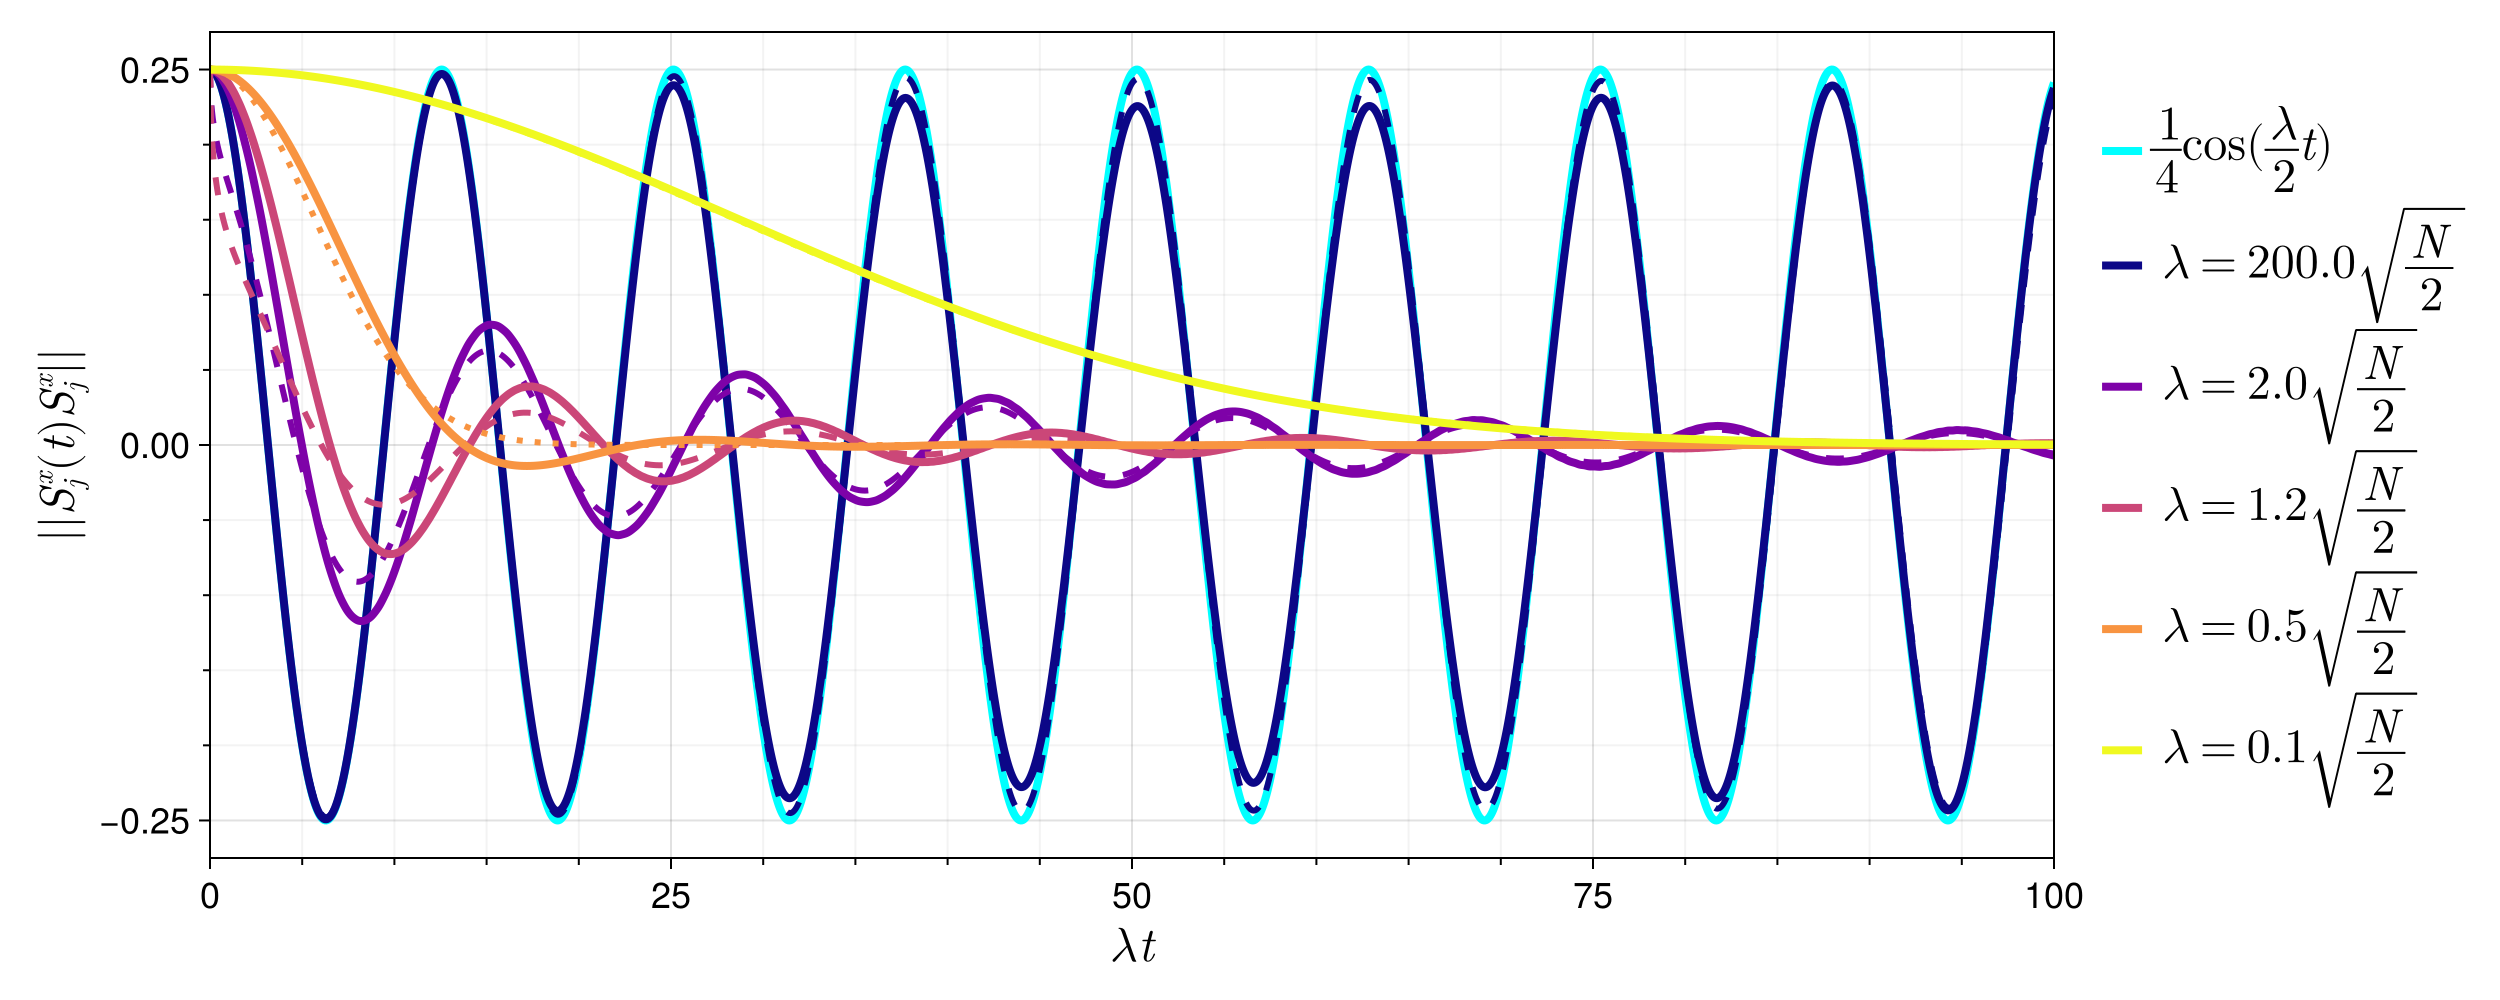

In [3]:
N = 1000;
tmax = 100.0
tpts = 2000
T_arr = range(0, tmax, length=tpts) ## array of λt values

fig = Figure(size = (1250, 500), font = "Latin Modern Roman")
ax = Axis(fig[1, 1],
    xlabel = L"\lambda t", xlabelsize = 24,
    ylabel = L"||S_j^x(t) S_j^x||", ylabelsize = 24,
    xgridvisible = true, xminorticks = IntervalsBetween(5), xminorticksvisible = true, xminorgridvisible = true,
    ygridvisible = true, yminorticks = IntervalsBetween(5), yminorticksvisible = true, yminorgridvisible = true,
    xticks = [0,25,50,75,100], yticks = [-0.25,0,0.25], xticklabelsize = 18, yticklabelsize = 18,
    limits = (0, tmax, nothing, nothing)
)
lines!(ax, T_arr, 0.25 .* cos.(T_arr ./ 2), 
    color = :cyan, linewidth = 4, label = L"\frac{1}{4}\cos(\frac{\lambda}{2} t)")

l_arr = [200.0, 2., 1.2, 0.5, 0.1] ## array of λ√N/2 values
lpts = length(l_arr)
colors = [(Makie.resample_cmap(:plasma, lpts))...]

for (j, l) in enumerate(l_arr)
    λ = l * sqrt(2/N)
    t_arr = T_arr ./ λ
    
    y_exact = [autocorr_exact_dynamics(t, λ, N=N) for t in t_arr]
    lines!(ax, T_arr, y_exact, 
        color = colors[j], linewidth = 4, 
        label = L"\lambda = %$l \sqrt{\frac{N}{2}}")

    if l < 1.0
        weak_vals = [weak_λ(t, λ, N=N) for t in t_arr]
        lines!(ax, T_arr, weak_vals, #label = "Weak-λ",
            color = colors[j], linewidth = 3, linestyle = :dot)
    end
    if l ≥ 1.0
        strong_vals = [strong_λ(t, λ, N=N) for t in t_arr]
        lines!(ax, T_arr, strong_vals, #label = "Strong-λ",
            color = colors[j], linewidth = 3, linestyle = :dash)
    end
end

Legend(fig[1, 2], ax, legendsize = 48, "", framevisible = false, labelsize = 24)

display(fig);


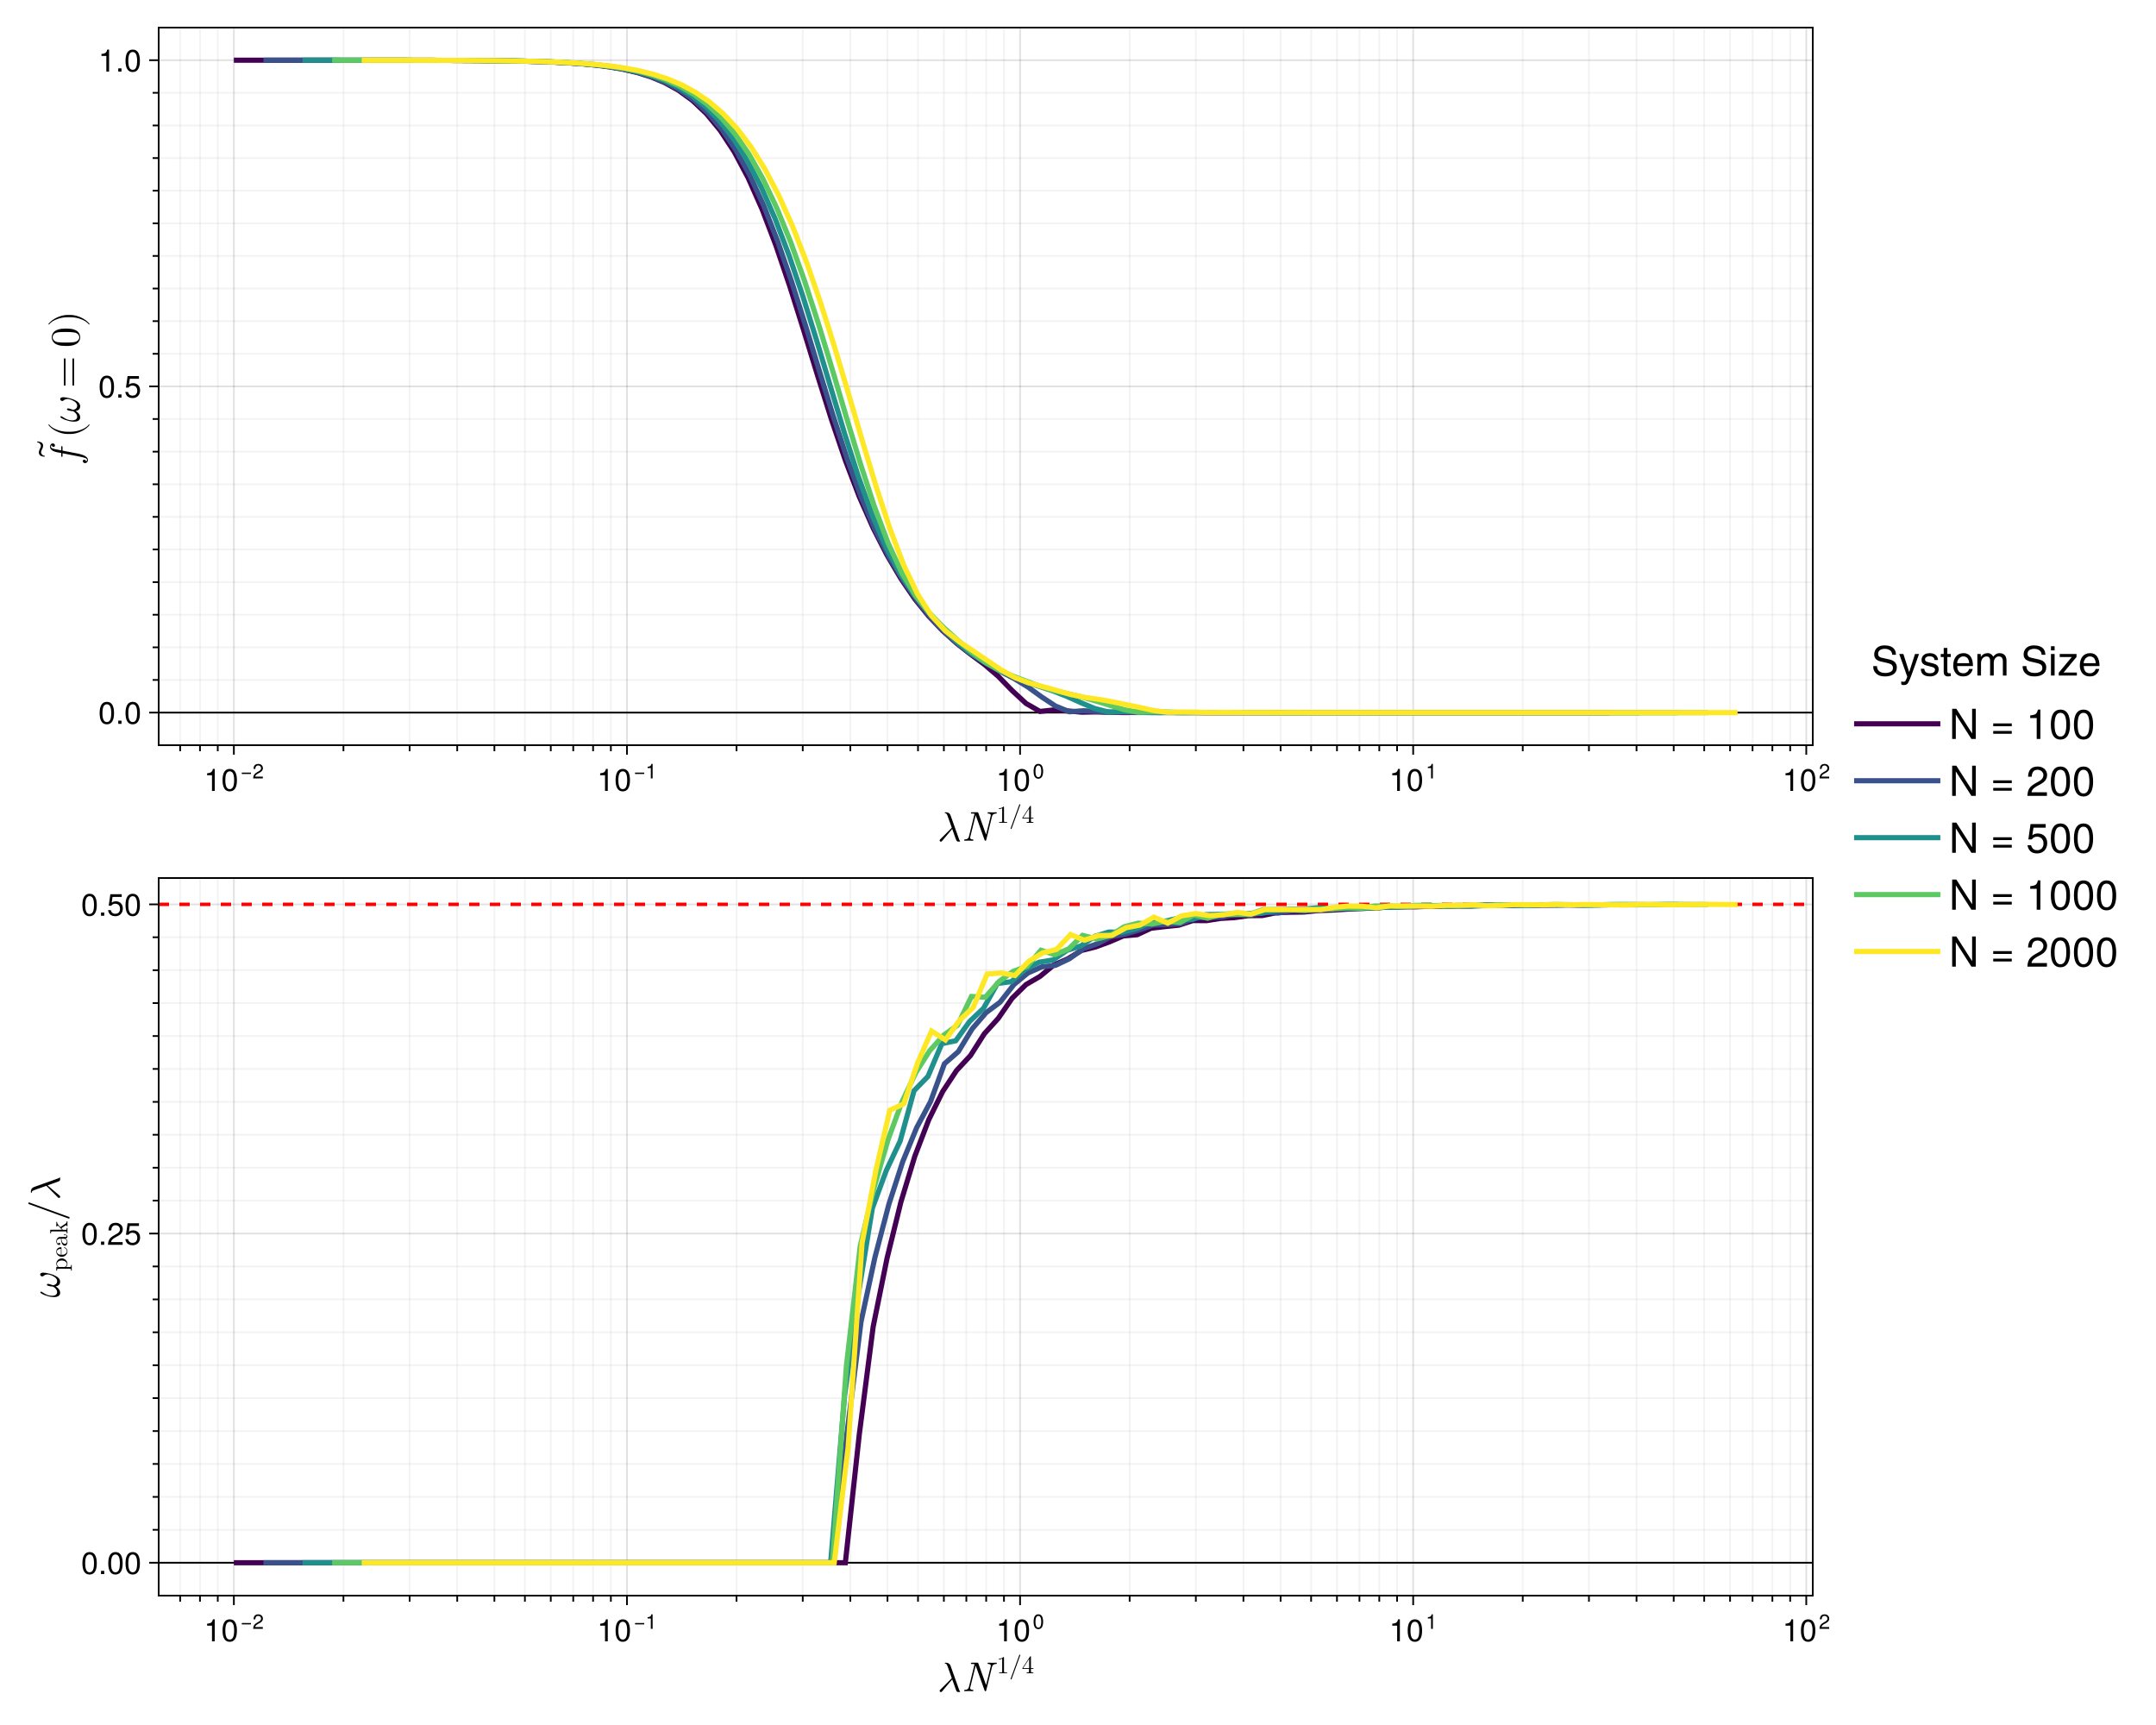

In [13]:
hA = 1.0
tmax = 200.
tpts = 5000
t_half = range(0, tmax, length=tpts); dt = t_half[2] - t_half[1];

num_lambdas = 100
lambdas = 10 .^ range(-2.5, 1.0, length=num_lambdas)

t_full = vcat(-reverse(t_half[2:end]), t_half)
N_t = length(t_full)

pad_factor = 4
N_pad = nextpow(2, N_t * pad_factor)

rfft_plan = plan_rfft(zeros(Float64, N_pad))
omegas = 2π .* rfftfreq(N_pad, 1/dt)

window = 0.5 .* (1 .- cos.(2π .* (0:N_t-1) ./ (N_t - 1)))

y_pad = zeros(Float64, N_pad)
y_pad_no_dc = zeros(Float64, N_pad)

N_vals = [100, 200, 500, 1000, 2000]
num_N = length(N_vals)
colors = Makie.resample_cmap(:viridis, num_N) 

fig = Figure(size = (1250, 1000), font="Helvetica")

# Plot 1: DC Component
ax1 = Axis(fig[1, 1], xscale = log10, 
        xlabel = L"\lambda N^{1/4}", xlabelsize = 24, xticklabelsize = 18,
        ylabel = L"\tilde{f}(\omega = 0)", ylabelsize = 24, yticklabelsize = 18,
        xgridvisible = true, xminorticks = IntervalsBetween(10), xminorticksvisible = true, xminorgridvisible = true,
        ygridvisible = true, yminorticks = IntervalsBetween(10), yminorticksvisible = true, yminorgridvisible = true,
)
hlines!(ax1, [0], label = "", linewidth = 1, color = :black)

# Plot 2: Peak Frequencies 
ax2 = Axis(fig[2, 1], xscale = log10, limits = (nothing, nothing, nothing, 0.52),
    xlabel = L"\lambda N^{1/4}", xlabelsize = 24, xticklabelsize = 18,
    ylabel = L"\omega_\mathrm{peak} / \lambda", ylabelsize = 24, yticks = [0,0.25,0.5], yticklabelsize = 18,
    xgridvisible = true, xminorticks = IntervalsBetween(10), 
    xminorticksvisible = true, xminorgridvisible = true,
    ygridvisible = true, yminorticks = IntervalsBetween(10), 
    yminorticksvisible = true, yminorgridvisible = true,
)
hlines!(ax2, [1/2], label = L"\omega = \lambda / 2", linewidth = 2, linestyle = :dash, color = :red)
hlines!(ax2, [0], label = "", linewidth = 1, color = :black)

linkxaxes!(ax1, ax2)

for (n_idx, N) in enumerate(N_vals)
    f_dc_vals    = zeros(num_lambdas)
    peak_w_raw   = zeros(num_lambdas)

    for (i, λ) in enumerate(lambdas)
        y_half = [autocorr_exact_dynamics(t, λ, N=N, hA=hA) for t in t_half]
        y_full = vcat(reverse(y_half[2:end]), y_half)
        
        y_windowed = y_full .* window
        fill!(y_pad, 0.0)
        y_pad[1:N_t] .= y_windowed
        
        Y_mag = abs.(rfft_plan * y_pad) .* dt
        f_dc_vals[i] = Y_mag[1]
                
        idx_peak_raw = argmax(Y_mag)
        peak_w_raw[i] = omegas[idx_peak_raw]
    end
    
    c = colors[n_idx]
    lines!(ax1, lambdas .* N^(1/4), 4/tmax .* f_dc_vals, linewidth = 3, color = c)
    lines!(ax2, lambdas .* N^(1/4), peak_w_raw ./ lambdas, 
           linewidth = 3, linestyle = :solid, color = c)
end

group_N = [LineElement(color = colors[i], linewidth = 3) for i in 1:num_N]
labels_N = ["N = $N" for N in N_vals]

Legend(fig[1:2, 2],
       [group_N],
       [labels_N],
       ["System Size"],
       framevisible = false,
       titlefont = "Helvetica-Bold", titlesize = 24,
       patchsize = (50, 30), labelsize = 24)

display(fig);